# Mental Health in Tech Survey — Data Analytics Project
**Analyst:** Dilshad Hussain | **Dataset:** OSMI Mental Health in Tech Survey (2014) — 1,259 responses, 27 columns | **Tools:** Python (pandas, matplotlib)

---
## Business Problem
Tech industry mein mental health ek hidden cost hai — productivity loss, attrition, absenteeism. Par companies ko pata nahi:
- Employees treatment kyun nahi lete, jabki problems hain?
- Company policies (benefits, leave, anonymity) ka actual impact kya hai?
- Kaunse levers pull karne se sabse zyada improvement milegi?

**Core question:** *Employee ke treatment-seeking behavior ko kaunse workplace factors drive karte hain, aur company kya concrete action le sakti hai?*

## Data Cleaning Summary
Raw data dikhne mein saaf tha, andar se ganda:
- **Age:** 8 absurd values (−1726, 5, 329, 99999999999) → median (31) se impute. Final range 18–72.
- **Gender:** 49 messy values (`M`, `Mail`, `msle`, `Cis Male `...) → 3 categories: Male (992), Female (251), Other (16).
- **Missing values:** state → "Not Applicable" (non-US log), self_employed → mode, work_interfere → "Not Applicable", comments → "No comment".
- **Result:** 0 nulls, 0 duplicates, correct dtypes.

**Note:** Har cleaning decision ek judgment call hai jo defend ho sake — formula nahi.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("survey_cleaned.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (1259, 27)

---
## Insight 1: Treatment rate 50.6% — par ye number biased hai

- **Observation:** 50.6% ne treatment liya, 49.4% ne nahi.
- **Why:** Survey OSMI (mental health advocacy group) ne karaya — self-selection bias. Jo log topic mein interested hain, wahi survey bharte hain. Real population rate isse kam hoga.
- **Business Impact:** Is number ko benchmark maanne wali company apni problem underestimate karegi.
- **Recommendation:** Directional insight ki tarah use karo, absolute benchmark nahi. Internal anonymous survey se apna baseline banao.
- **Analyst Learning — Selection Bias:** Data *kahan se aaya*, ye analysis se pehle ka sawal hai.

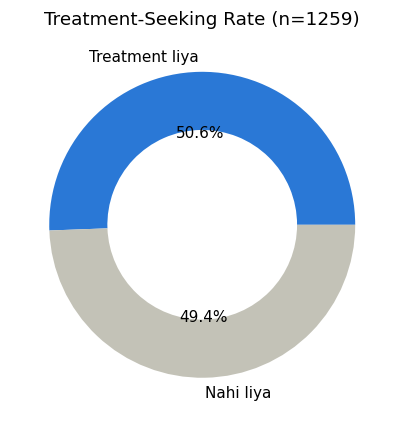

In [ ]:
t = df['treatment'].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(t, labels=['Treatment liya', 'Nahi liya'], autopct='%1.1f%%',
       colors=['#2a78d6', '#c3c2b7'], wedgeprops=dict(width=0.38))
ax.set_title('Treatment-Seeking Rate (n=1259)')
plt.tight_layout(); plt.show()

---
## Insight 2: Family history = sabse bada predictor (+38.7 points)

- **Observation:** Family history walon mein 74.2% treatment vs 35.5% bina family history ke.
- **Why (2 hypotheses, dono valid):** (a) Genetic/environmental risk genuinely zyada. (b) Jin gharon mein topic khula hai, wahan help lena normalized hai.
- **Business Impact:** Sirf "awareness campaigns" chalane wali companies asli lever miss kar rahi hain — lever hai **normalization**.
- **Recommendation:** Leadership storytelling programs — senior log experiences share karein, family-openness effect workplace mein replicate hoga.
- **Analyst Learning — Confounding:** Ek number ke multiple explanations. Data alone decide nahi karta kaunsa sahi hai — dono report karna strength hai.

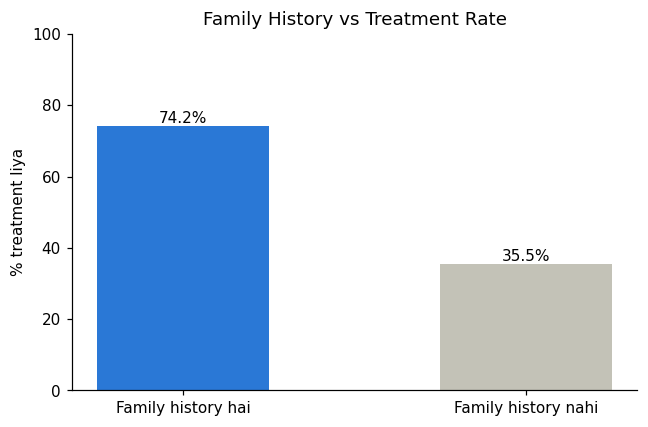

In [ ]:
fh = pd.crosstab(df['family_history'], df['treatment'], normalize='index')['Yes'] * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Family history hai', 'Family history nahi'], [fh['Yes'], fh['No']],
              color=['#2a78d6', '#c3c2b7'], width=0.5)
ax.bar_label(bars, fmt='%.1f%%')
ax.set_ylabel('% treatment liya'); ax.set_ylim(0, 100)
ax.set_title('Family History vs Treatment Rate')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Insight 3: Stigma Gap — dataset ka sabse powerful finding

- **Observation:** Interview mein physical health problem 16% discuss karenge; mental health sirf **3.5%**. Clear "No": physical 39.7% vs mental 80.1%. Gap = **4.5x**.
- **Why:** Mental illness = "weak/risky hire" perception. Physical illness ko sympathy, mental ko suspicion.
- **Business Impact:** Ye stigma hiring pipeline aur internal disclosure dono poison karta hai. Untreated employees = silent productivity loss.
- **Recommendation:** Disclosure-safe policies — anonymous EAP access, no-questions-asked mental health days. Disclosure unsafe hai toh har wellness program underutilized rahega.
- **Analyst Learning — Baseline Comparison:** 3.5% akela meaningless hai. Physical (16%) ke against rakha toh story bani. Har number se poochho: **"compared to what?"**

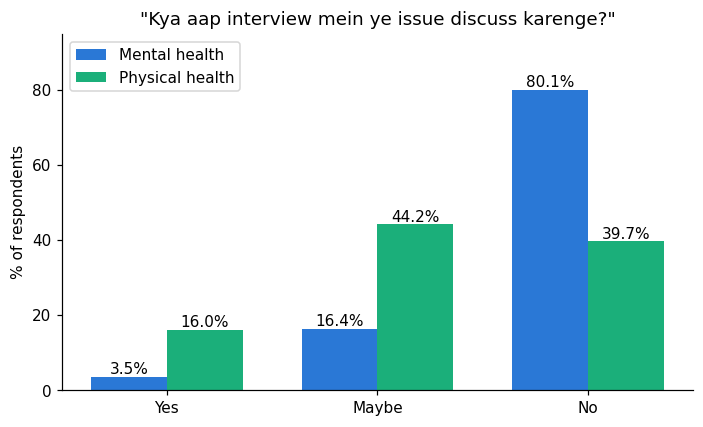

In [ ]:
mh = df['mental_health_interview'].value_counts(normalize=True) * 100
ph = df['phys_health_interview'].value_counts(normalize=True) * 100
labels = ['Yes', 'Maybe', 'No']
x = range(len(labels)); w = 0.36
fig, ax = plt.subplots(figsize=(6.5, 4))
b1 = ax.bar([i - w/2 for i in x], [mh[l] for l in labels], w, label='Mental health', color='#2a78d6')
b2 = ax.bar([i + w/2 for i in x], [ph[l] for l in labels], w, label='Physical health', color='#1baf7a')
ax.bar_label(b1, fmt='%.1f%%'); ax.bar_label(b2, fmt='%.1f%%')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('% of respondents'); ax.set_ylim(0, 95)
ax.set_title('"Kya aap interview mein ye issue discuss karenge?"')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Insight 4: Leave difficulty × fear — perfect staircase

- **Observation:** Fear of negative consequences: Very easy → 8.7%, Somewhat easy → 12.8%, Somewhat difficult → 42.9%, Very difficult → **62.2%**. Monotonic — ek bhi step ulta nahi.
- **Why:** Leave policy rule nahi, **culture ka signal** hai. Chhutti mushkil = "yahan mental health seriously nahi liya jaata."
- **Business Impact:** High-fear environment mein problems crisis-stage tak chhupti hain — tab cost 10x (sick leave, attrition, replacement hiring).
- **Recommendation:** Cheapest high-impact fix — leave approval se manager hatao, HR-direct/self-serve route do.
- **Analyst Learning — Proxy Metrics:** "Culture" measure nahi hota; "leave kitni easy hai" uska measurable proxy hai. Unmeasurable ka proxy dhoondhna analyst ka core skill hai.

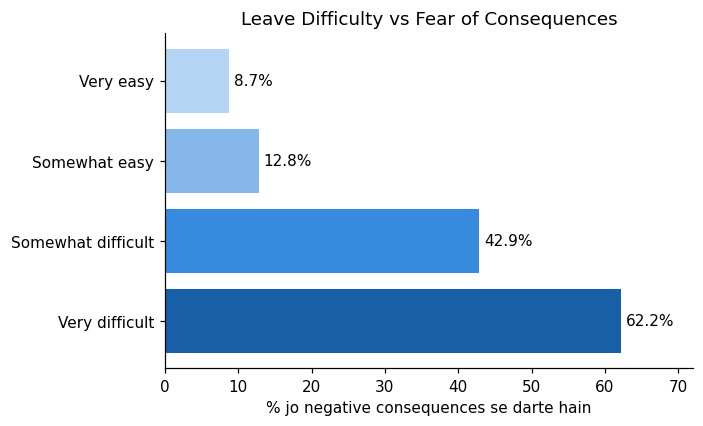

In [ ]:
order = ['Very easy', 'Somewhat easy', 'Somewhat difficult', 'Very difficult']
lv = pd.crosstab(df['leave'], df['mental_health_consequence'], normalize='index')['Yes'] * 100
vals = [lv[o] for o in order]
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.barh(order[::-1], vals[::-1], color=['#185fa5', '#378add', '#85b7eb', '#b5d4f4'])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('% jo negative consequences se darte hain'); ax.set_xlim(0, 72)
ax.set_title('Leave Difficulty vs Fear of Consequences')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Insight 5: Company size × benefits — do alag problems ek chart mein

- **Observation:** Benefits "Yes": 1–5 employees → 11.7%; 1000+ → 64.9%. **Twist:** mid-size (26–500) mein 36–39% ko *pata hi nahi* ("Don't know") ki benefits hain ya nahi.
- **Why:** Chhoti companies — genuine budget constraint. Mid-size — benefits *hain* par communication zero. Paisa spend, value zero.
- **Business Impact:** Mid-size companies ka benefits spend partly waste ho raha hai — employees use hi nahi karte kyunki khabar nahi.
- **Recommendation:** Mid-size: benefits *badhao mat, batao* — onboarding module + quarterly reminders (near-zero cost). Small: pooled/group EAP plans.
- **Analyst Learning — "Don't know" is data:** Beginner ambiguous category drop karta hai; senior usme insight dhoondhta hai. Yahan "Don't know" = communication failure ka direct evidence.

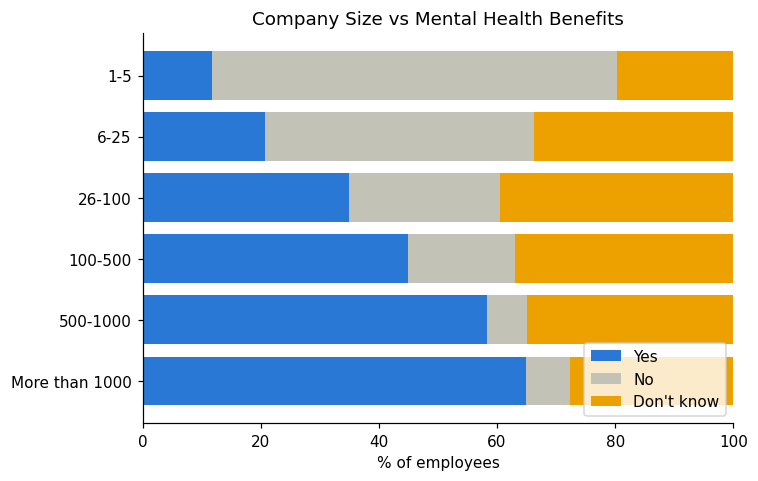

In [ ]:
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
bt = pd.crosstab(df['no_employees'], df['benefits'], normalize='index').loc[order] * 100
fig, ax = plt.subplots(figsize=(7, 4.5))
left = [0]*len(order)
for col, color in [('Yes', '#2a78d6'), ('No', '#c3c2b7'), ("Don't know", '#eda100')]:
    ax.barh(order[::-1], bt[col][::-1], left=left[::-1] if isinstance(left, list) else left, color=color, label=col)
    left = [l + v for l, v in zip(left, bt[col])]
ax.set_xlabel('% of employees'); ax.set_xlim(0, 100)
ax.set_title('Company Size vs Mental Health Benefits')
ax.legend(loc='lower right'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Insight 6: Gender gap — help-seeking ka, illness ka nahi

- **Observation:** Treatment rate — Female: 68.9%, Male: 45.4%, Other: 87.5% (**n=16 — small sample, weight mat do**).
- **Why:** Ye illness gap nahi, **help-seeking behavior gap** hai. "Mard ko dard nahi hota" conditioning — men problems dabate hain.
- **Business Impact:** Male-dominated tech workforce mein majority untreated = sabse bada silent attrition risk pool.
- **Recommendation:** Male-targeted interventions — anonymous channels, peer-led groups. Generic wellness posters men tak nahi pahunchte.
- **Analyst Learning — Measurement vs Reality:** Column measure karta hai "treatment liya?", not "bimaar hai?". **Bonus — Small Sample Warning:** 16 ka 87.5% = sirf 14 log; chhote group ke % unstable hote hain.

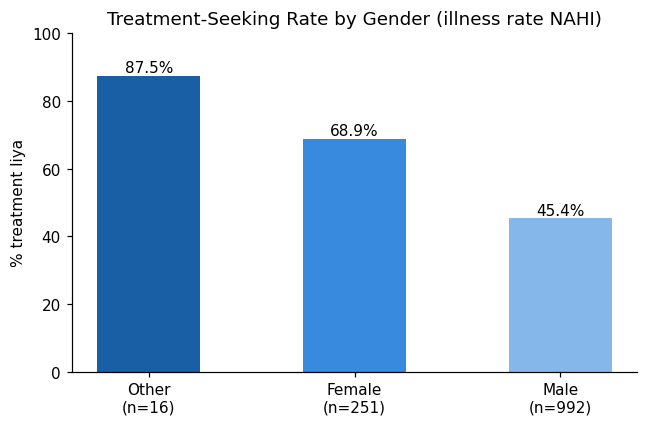

In [ ]:
g = pd.crosstab(df['gender'], df['treatment'], normalize='index')['Yes'] * 100
order = ['Other', 'Female', 'Male']
n = df['gender'].value_counts()
labels = [f"{o}\n(n={n[o]})" for o in order]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, [g[o] for o in order], color=['#185fa5', '#378add', '#85b7eb'], width=0.5)
ax.bar_label(bars, fmt='%.1f%%')
ax.set_ylabel('% treatment liya'); ax.set_ylim(0, 100)
ax.set_title('Treatment-Seeking Rate by Gender (illness rate NAHI)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Insight 7: Remote work — no meaningful difference (null finding)

- **Observation:** Treatment rate — remote: 52.7%, office: 49.7%. Difference 3 points = practically zero.
- **Why:** 2014 mein remote work rare aur self-selected tha — jo remote the, wo already flexible companies mein the.
- **Business Impact:** "Remote work mental health bigaadta hai" wali policy is data se justify nahi hoti.
- **Recommendation:** Remote policy is factor pe base mat karo; leave ease aur benefits communication pe focus karo — wahan signal strong hai.
- **Analyst Learning — Null Findings:** Difference na milna bhi valid result hai. "No effect found" honestly report karna trust banata hai; fake patterns credibility khatam karte hain.

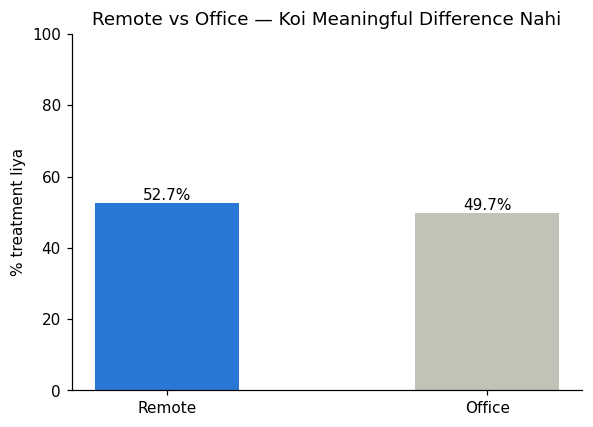

In [ ]:
r = pd.crosstab(df['remote_work'], df['treatment'], normalize='index')['Yes'] * 100
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['Remote', 'Office'], [r['Yes'], r['No']], color=['#2a78d6', '#c3c2b7'], width=0.45)
ax.bar_label(bars, fmt='%.1f%%')
ax.set_ylabel('% treatment liya'); ax.set_ylim(0, 100)
ax.set_title('Remote vs Office — Koi Meaningful Difference Nahi')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Trends, Correlations & Anomalies

**Trends:**
- Company size ↑ → benefits availability ↑ (11.7% → 64.9%)
- Leave difficulty ↑ → fear ↑ (8.7% → 62.2%, perfect staircase)
- Work interference ↑ → treatment ↑ (Never: 14.1% → Often: 85.4%) — severity treatment drive karti hai

**Correlations (categorical data note):**
- Data mostly categorical hai — Pearson correlation apply nahi hota. Relationships normalized crosstabs se nikale. Formal testing = chi-square / Cramér's V (future scope).
- Strongest: family_history × treatment, leave × fear, work_interfere × treatment.

**Anomalies:**
- Age: −1726 aur 99 billion jaise values — data entry/troll responses (cleaned).
- Gender: 49 free-text values — survey design flaw (free-text instead of dropdown). Root cause data *collection* stage pe hai.
- **Fear-supervisor paradox:** Jo darte hain, unme se sirf 9.2% supervisor se baat karte hain vs 72.7% jo nahi darte. Fear communication ko exactly tab kill karta hai jab wo sabse zaroori hai.

## Recommendations (Priority Order)
1. **Leave friction hatao** — HR-direct route (cheapest, fastest, staircase directly address hota hai)
2. **Benefits communication fix** (mid-size) — onboarding + quarterly reminders
3. **Anonymity guarantee + loudly communicate** — anonymity "Yes" walon ka treatment rate 60.8% vs 45.3%
4. **Male-targeted channels** — anonymous, peer-led
5. **Leadership normalization** — senior storytelling

## Key Learnings
1. Selection bias — sample ka source pehle check karo
2. Confounding — multiple explanations acknowledge karo
3. Baseline comparison — "compared to what?"
4. Proxy metrics — unmeasurable ke measurable proxies
5. "Don't know" is data
6. Measurement vs reality — column ka meaning samjho
7. Null findings — "no effect" bhi valuable hai
8. Data cleaning is judgment — har decision defensible ho

## Conclusion
Tech workplace mein mental health treatment ka sabse bada barrier resources nahi, **safety aur communication** hai. Sabse actionable levers sasti hain: leave friction hatao, benefits batao, anonymity guarantee karo. **Data ka clear message: fear kam karo, treatment khud badhega.**

## Future Scope
- Chi-square / Cramér's V se formal validation
- Logistic regression — treatment prediction model
- OSMI newer surveys (2016+) se time-trend comparison
- Comments column ka text/sentiment analysis
- Power BI interactive dashboard